# Final Project

#### Imports

In [2]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import v2
import matplotlib.pyplot as plt
import pandas as pd
import string
import time
import os
from datetime import datetime

# Use GPU if available, fall back to CPU otherwise
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

torch.backends.cudnn.benchmark = True

NUM_WORKERS = min(4, os.cpu_count() or 1)
PIN_MEMORY = device.type == "cuda"

Using device: cuda


#### Loading Dataset
b) Download the EMNIST dataset. Note that it contains 6 variants, so called splits, which differ in size and contents. For the first half of the project, you should be using the ‘letters’ split. After loading the dataset, plot a random selection of image samples and the corresponding labels (similar to Figure 1.).

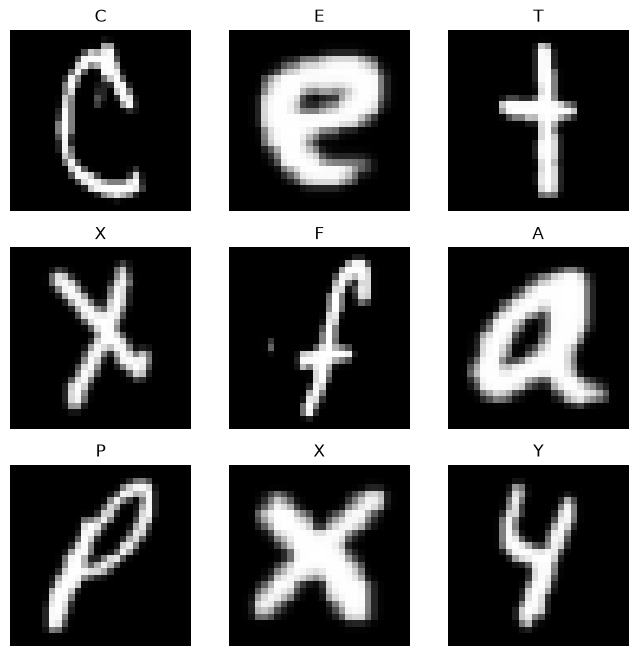

In [3]:
training_data = datasets.EMNIST(
    root="data",
    split="letters",
    train=True,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)

test_data = datasets.EMNIST(
    root="data",
    split="letters",
    train=False,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)

letters = ["N/A"] + list(string.ascii_uppercase)

figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(letters[label])
    plt.axis("off")
    plt.imshow(img.squeeze().T, cmap="gray")
plt.show()

#### Basic learning functionality
c) Implement a program that defines the simple CNN model depicted in see Figure 2. and trains letter classification on the loaded dataset from step b). Implement two functions that use the given model and respective dataset for training and testing. Using cross entropy loss can be a convenient loss function, since it does not require normalized input. In addition, your program should visualize (plot) the training loss and record the total training time.

##### Create Data Loader

In [4]:
batch_size = 512

training_loader = DataLoader(
    training_data,
    batch_size=batch_size,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=NUM_WORKERS > 0,
)

test_loader = DataLoader(
    test_data,
    batch_size=batch_size,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=NUM_WORKERS > 0,
)


##### Define CNN

In [5]:
class Model:
    def __init__(self, model, learning_rate, batch_size, description="simple-cnn", device=device):
        self.device = device
        self.model = model.to(self.device)
        self.criterion = torch.nn.CrossEntropyLoss()
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=learning_rate)
        self.learning_rate = learning_rate
        self.batch_size = batch_size
        self.layers = sum(1 for _ in self.model.modules()) - 1
        self.description = description

    # TRAINING FUNCTION
    def train(self, loader):
        self.model.train()

        running_loss = 0
        batch_losses = []

        for images, labels in loader:
            images = images.to(self.device)
            labels = labels.to(self.device) - 1

            self.optimizer.zero_grad()

            outputs = self.model(images)
            loss = self.criterion(outputs, labels)

            loss.backward()
            self.optimizer.step()

            running_loss += loss.item()
            batch_losses.append(loss.item())

        average_loss = running_loss / len(loader)

        return average_loss, batch_losses

    # TESTING FUNCTION
    def test(self, loader):
        self.model.eval()

        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in loader:
                images = images.to(self.device)
                labels = labels.to(self.device) - 1

                outputs = self.model(images)
                predictions = outputs.argmax(dim=1)

                correct += (predictions == labels).sum().item()
                total += labels.size(0)

        accuracy = 100 * correct / total
        return accuracy

    # SAVE MODEL HELPER FUNCTION
    def save_model(self, loss_history=None, epochs=0, accuracy=None, model_dir="models", figs_dir="figs", show_plot=False):
        os.makedirs(model_dir, exist_ok=True)
        os.makedirs(figs_dir, exist_ok=True)

        timestamp = datetime.now().strftime("%Y%m%d-%H%M%S")
        acc_part = f"_acc{accuracy:.2f}" if accuracy is not None else ""

        base_name = (
            f"cnn_{self.description}"
            f"_epo{epochs}"
            f"_lr{self.learning_rate}"
            f"_bs{self.batch_size}"
            f"_lay{self.layers}"
            f"_optAdam"
            f"{acc_part}"
            f"_{timestamp}"
        )

        model_path = os.path.join(model_dir, base_name + ".pth")
        torch.save(self.model.state_dict(), model_path)
        print(f"Model saved to: {model_path}")

        if loss_history is not None and epochs != 0:
            fig_path = os.path.join(figs_dir, base_name + "_loss_history.png")
            save_loss_plot(loss_history, filename=fig_path, show_plot=show_plot)
            print(f"Plot saved to: {fig_path}")

        return model_path

##### Training Loop

In [6]:
def training_loop(model, epochs, train_loader, test_loader, verbose=True):
    loss_history = []

    start_time = time.time()

    for epoch in range(epochs):
        avg_loss, batch_losses = model.train(train_loader)
        loss_history.append(batch_losses)

        accuracy = model.test(test_loader)

        if verbose:
            print(
                f"Epoch {epoch+1}/{epochs}  "
                f"Loss {avg_loss:.4f}  "
                f"Accuracy {accuracy:.2f}%"
            )

    training_time = time.time() - start_time

    if verbose:
        print(f"\nTraining time: {training_time:.2f} seconds")

    return loss_history, training_time


##### Training Loss Plot

In [7]:
def save_loss_plot(loss_history, filename, show_plot=False):
    plt.figure(figsize=(8, 5))

    for epoch, losses in enumerate(loss_history):
        plt.plot(losses, label=f"Epoch {epoch+1}")

    plt.xlabel("Batch")
    plt.ylabel("Loss")
    plt.title("Training Loss per Batch")
    plt.legend()
    plt.savefig(filename)

    if show_plot:
        plt.show()
    else:
        plt.close()


## Define Simple CNN Model

In [ ]:
def make_simple_architecture():
    return torch.nn.Sequential(
        torch.nn.Conv2d(in_channels=1, out_channels=8, kernel_size=5, padding=2),
        torch.nn.ReLU(),
        torch.nn.MaxPool2d(kernel_size=2, stride=2),
        torch.nn.Flatten(),
        torch.nn.Linear(in_features=8 * 14 * 14, out_features=26),
    )

### Task B - b) Adding more Layers

In [ ]:
def make_architecture_1():
    # Two convolutions before a single pool at the end ("pooling-at-end")
    return torch.nn.Sequential(
        torch.nn.Conv2d(in_channels=1, out_channels=8, kernel_size=5, padding=2),
        torch.nn.ReLU(),
        torch.nn.Conv2d(in_channels=8, out_channels=8, kernel_size=5, padding=2),
        torch.nn.ReLU(),
        torch.nn.MaxPool2d(kernel_size=2, stride=2),
        torch.nn.Flatten(),
        torch.nn.Linear(in_features=8 * 14 * 14, out_features=26),
    )

In [ ]:
def make_architecture_2():
    # Pool after each conv ("pooling-between")
    return torch.nn.Sequential(
        torch.nn.Conv2d(in_channels=1, out_channels=8, kernel_size=5, padding=2),
        torch.nn.ReLU(),
        torch.nn.MaxPool2d(kernel_size=2, stride=2),
        torch.nn.Conv2d(in_channels=8, out_channels=16, kernel_size=5, padding=2),
        torch.nn.ReLU(),
        torch.nn.MaxPool2d(kernel_size=2, stride=2),
        torch.nn.Flatten(),
        torch.nn.Linear(in_features=16 * 7 * 7, out_features=26),
    )

In [ ]:
def make_architecture_3():
    # Adds a hidden fully-connected layer before the output ("more-layers")
    return torch.nn.Sequential(
        torch.nn.Conv2d(in_channels=1, out_channels=8, kernel_size=5, padding=2),
        torch.nn.ReLU(),
        torch.nn.MaxPool2d(kernel_size=2, stride=2),
        torch.nn.Conv2d(in_channels=8, out_channels=16, kernel_size=5, padding=2),
        torch.nn.ReLU(),
        torch.nn.MaxPool2d(kernel_size=2, stride=2),
        torch.nn.Flatten(),
        torch.nn.Linear(in_features=16 * 7 * 7, out_features=64),
        torch.nn.ReLU(),
        torch.nn.Linear(in_features=64, out_features=26),
    )

### c) number of feature maps and the Size of the convolution Kernel

In [ ]:
def make_architecture_4():
    # More feature maps: 16 -> 32 instead of 8 -> 16 ("more-feature-maps")
    return torch.nn.Sequential(
        torch.nn.Conv2d(in_channels=1, out_channels=16, kernel_size=5, padding=2),
        torch.nn.ReLU(),
        torch.nn.MaxPool2d(kernel_size=2, stride=2),
        torch.nn.Conv2d(in_channels=16, out_channels=32, kernel_size=5, padding=2),
        torch.nn.ReLU(),
        torch.nn.MaxPool2d(kernel_size=2, stride=2),
        torch.nn.Flatten(),
        torch.nn.Linear(in_features=32 * 7 * 7, out_features=64),
        torch.nn.ReLU(),
        torch.nn.Linear(in_features=64, out_features=26),
    )

In [ ]:
def make_architecture_5():
    # Larger convolution kernels: 5x5 instead of 3x3 ("larger-kernels")
    return torch.nn.Sequential(
        torch.nn.Conv2d(in_channels=1, out_channels=8, kernel_size=7, padding=3),
        torch.nn.ReLU(),
        torch.nn.MaxPool2d(kernel_size=2, stride=2),
        torch.nn.Conv2d(in_channels=8, out_channels=16, kernel_size=7, padding=3),
        torch.nn.ReLU(),
        torch.nn.MaxPool2d(kernel_size=2, stride=2),
        torch.nn.Flatten(),
        torch.nn.Linear(in_features=16 * 7 * 7, out_features=64),
        torch.nn.ReLU(),
        torch.nn.Linear(in_features=64, out_features=26),
    )


## Automated Experiments

In [14]:
experiments = [
    # --- Architecture comparison (task b/c) ---
    {"name": "simple-cnn",        "arch_fn": make_simple_architecture, "lr": 0.001,  "batch_size": 512, "epochs": 5},
    {"name": "pooling-at-end",    "arch_fn": make_architecture_1,      "lr": 0.001,  "batch_size": 512, "epochs": 5},
    {"name": "pooling-between",   "arch_fn": make_architecture_2,      "lr": 0.001,  "batch_size": 512, "epochs": 5},
    {"name": "more-layers",       "arch_fn": make_architecture_3,      "lr": 0.001,  "batch_size": 512, "epochs": 5},
    {"name": "more-feature-maps", "arch_fn": make_architecture_4,      "lr": 0.001,  "batch_size": 512, "epochs": 5},
    {"name": "larger-kernels",    "arch_fn": make_architecture_5,      "lr": 0.001,  "batch_size": 512, "epochs": 5},

    # --- Learning-rate sweep using architecuture 5 as base (best one currently, afaik) ---
    {"name": "lr-0.01",           "arch_fn": make_architecture_5,      "lr": 0.01,   "batch_size": 512, "epochs": 5},
    {"name": "lr-0.0001",         "arch_fn": make_architecture_5,      "lr": 0.0001, "batch_size": 512, "epochs": 5},

    # --- Batch-size sweep ---
    {"name": "batch-64",          "arch_fn": make_architecture_5,      "lr": 0.001,  "batch_size": 64,  "epochs": 5},
    {"name": "batch-256",         "arch_fn": make_architecture_5,      "lr": 0.001,  "batch_size": 256, "epochs": 5},

    # --- Epoch sweep ---
    {"name": "epochs-3",          "arch_fn": make_architecture_5,      "lr": 0.001,  "batch_size": 512, "epochs": 3},
    {"name": "epochs-10",         "arch_fn": make_architecture_5,      "lr": 0.001,  "batch_size": 512, "epochs": 10},
]

print(f"{len(experiments)} experiments queued.")


12 experiments queued.


In [15]:
results = []

for cfg in experiments:
    print(f"\n=== Running experiment: {cfg['name']} ===")

    architecture = cfg["arch_fn"]()
    exp_train_loader = DataLoader(
            training_data, batch_size=cfg["batch_size"], shuffle=True,
            num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, persistent_workers=NUM_WORKERS > 0,
    )
    exp_test_loader = DataLoader(
            test_data, batch_size=cfg["batch_size"], shuffle=False,
            num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, persistent_workers=NUM_WORKERS > 0,
    )

    model = Model(
        architecture,
        learning_rate=cfg["lr"],
        batch_size=cfg["batch_size"],
        description=cfg["name"],
    )

    loss_history, training_time = training_loop(
        model,
        epochs=cfg["epochs"],
        train_loader=exp_train_loader,
        test_loader=exp_test_loader,
    )
    accuracy = model.test(exp_test_loader)

    results.append({
        "name": cfg["name"],
        "learning_rate": cfg["lr"],
        "batch_size": cfg["batch_size"],
        "epochs": cfg["epochs"],
        "layers": model.layers,
        "accuracy": accuracy,
        "training_time_sec": training_time,
        "model": model,
        "loss_history": loss_history,
    })

results_df = pd.DataFrame(
    [{k: v for k, v in r.items() if k not in ("model", "loss_history")} for r in results]
).sort_values("accuracy", ascending=False).reset_index(drop=True)

results_df



=== Running experiment: simple-cnn ===


RuntimeError: mat1 and mat2 shapes cannot be multiplied (512x1352 and 1568x26)

Visual Comparison

In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(results_df["name"], results_df["accuracy"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Test accuracy (%)")
plt.title("Experiment comparison")
plt.tight_layout()
plt.show()


Save the best performer

In [ ]:
best = max(results, key=lambda r: r["accuracy"])

print(f"Best experiment: {best['name']}")
print(f"  Accuracy:      {best['accuracy']:.2f}%")
print(f"  Learning rate: {best['learning_rate']}")
print(f"  Batch size:    {best['batch_size']}")
print(f"  Epochs:        {best['epochs']}")
print(f"  Training time: {best['training_time_sec']:.2f}s")

best_model_path = best["model"].save_model(
    loss_history=best["loss_history"],
    epochs=best["epochs"],
    accuracy=best["accuracy"],
    show_plot=True,
)
